In [1]:
import copy
import numpy as np
import bz2
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams["mathtext.fontset"] = 'cm'
mpl.rcParams['text.usetex'] = True
from cycler import cycler
import helper_functions as hf
import scipy.signal as signal
import pickle
import scipy.stats as stats
import networkx as nx
import os
root_folder = 'May24'
folder = root_folder+'/Data/'
ifile = bz2.BZ2File(folder + 'CTM_Aug24.pkl', 'rb')
CTM = pickle.load(ifile)
ifile.close()
ifile = bz2.BZ2File(folder + 'CMT_Aug24.pkl', 'rb')
CMT = pickle.load(ifile)
ifile.close()
print('***All dictionaries were loaded***')
behaviors = ['Jump', 'Undefined', 'Floor licking', 'Wall licking', 'Grooming', 'Body licking', 'Rearing', 'Locomotion', 'Stationary']
colors = ["#696969", "#d3d3d3", "#d73027", "#e57373", "#c4a7e7", "#8e63b8", "#b3e5fc", "#3399cc", "#1f4e79"]
lut = np.array([4,5,3,2,6,1,8,7,0])
# Your existing configuration
# Set the font path for Arial
arial_font_path = 'C:/Windows/Fonts/arial.ttf'

# Configure Matplotlib to use Arial with LaTeX
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['pdf.fonttype'] = 42  # Ensure fonts are embedded
mpl.rcParams['ps.fonttype'] = 42  # Ensure fonts are embedded

# Set specific font paths if necessary
mpl.rcParams['font.sans-serif'] = [arial_font_path]

# Adjust text sizes
SMALL_SIZE = 8
MEDIUM_SIZE = 10
LARGE_SIZE = 12

plt.rc('font', size=SMALL_SIZE)          # Controls default text size
plt.rc('axes', titlesize=MEDIUM_SIZE)    # Controls title size
plt.rc('axes', labelsize=MEDIUM_SIZE)    # Controls x and y label size
plt.rc('xtick', labelsize=SMALL_SIZE)    # Controls x tick label size
plt.rc('ytick', labelsize=SMALL_SIZE)    # Controls y tick label size
plt.rc('legend', fontsize=SMALL_SIZE)    # Controls legend font size

SSD_color = '#CC6677'
velocity_color = '#44AA99'
FPS=15
sample_rate=15
second = 15
minute = 60*second
# mpl.rcParams['xtick.labelsize']=10
# mpl.rcParams['ytick.labelsize']=10
# mpl.rcParams['legend.fontsize']=8
GR = 0
BL = 1
WL = 2
FL = 3
trials  = ['saline1','saline2','saline3','cocaine1','cocaine2','cocaine3','cocaine4','cocaine5']
cohorts = ['drd1_hm4di','drd1_hm3dq','controls','a2a_hm4di','a2a_hm3dq','a2a_opto']
num_of_trials = len(trials)
num_of_behaviors = len(behaviors)
MT = {}
TM = {}
for c in cohorts:
    for m in CMT[c]:
        MT[m] = copy.deepcopy(CMT[c][m])
        for t in MT[m]:
            MT[m][t]['merged'] =  lut[MT[m][t]['merged']]
for cohort in cohorts:
    for mouse in CMT[cohort].keys():
        for t in CMT[cohort][mouse].keys():
            if t not in TM.keys():
                TM[t] = {}
            TM[t][mouse] = copy.deepcopy(CMT[cohort][mouse][t])
            TM[t][mouse]['merged'] = lut[TM[t][mouse]['merged']]
del CMT
del CTM

EGO_LICKING = 0
ALLO_LICKING = 1
NO_LICKING = 2
lut = np.array([EGO_LICKING,EGO_LICKING,ALLO_LICKING,ALLO_LICKING,NO_LICKING,NO_LICKING,NO_LICKING,NO_LICKING,NO_LICKING,NO_LICKING])

***All dictionaries were loaded***


In [ ]:
# Setup output folder
output_folder = root_folder + '/Figures/Stereotypies_development/Summary/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Initialize data structures
num_of_mice = []
max_num_of_mice = 0
for t in trials:
    max_num_of_mice = np.max([max_num_of_mice, len(TM[t].keys())])
    num_of_mice.append(len(TM[t].keys()))

fraction_of_frames = np.empty((num_of_behaviors, num_of_trials, max_num_of_mice))
fraction_of_frames[:, :, :] = np.nan
clustered_fraction_of_frames = np.empty((3, num_of_trials, max_num_of_mice))
clustered_fraction_of_frames[:, :, :] = np.nan

# Process behavior data
t_idx = 0
for t in trials:
    m_idx = 0
    for m in TM[t]:
        # print(t, m)
        predictions = TM[t][m]['merged']
        for b in range(len(behaviors)):
            fraction_of_frames[b, t_idx, m_idx] = np.count_nonzero(predictions == b) / predictions.size
        clustered_predictions = lut[predictions]
        clustered_fraction_of_frames[EGO_LICKING, t_idx, m_idx] = np.count_nonzero(clustered_predictions == EGO_LICKING) / predictions.size
        clustered_fraction_of_frames[ALLO_LICKING, t_idx, m_idx] = np.count_nonzero(clustered_predictions == ALLO_LICKING) / predictions.size
        clustered_fraction_of_frames[NO_LICKING, t_idx, m_idx] = np.count_nonzero(clustered_predictions == NO_LICKING) / predictions.size
        m_idx += 1
    t_idx += 1

plt.figure(figsize=(1.83,1.81))  # Increase the figure size

# Define the new order of behaviors
new_behavior_order = ['Stationary', 'Locomotion', 'Rearing', 'Grooming', 'Body licking', 'Wall licking', 'Floor licking', 'Jump', 'Undefined']

# Plot mean and standard error for each behavior
for behavior in new_behavior_order:
    b = behaviors.index(behavior)
    mean = np.nanmean(fraction_of_frames[b], axis=1)
    stderr = np.sqrt(np.nanvar(fraction_of_frames[b], axis=1) / np.array(num_of_mice))
    plt.plot(mean, color=colors[b], label=behavior, ls='--', lw=1, marker='o', ms=2, markerfacecolor='white')
    plt.errorbar(np.arange(num_of_trials), y=mean, yerr=stderr, color=colors[b], capsize=2, capthick=1, ls='', elinewidth=1)

# Adjust y-ticks and labels
plt.yticks(np.arange(0, 1.1, 0.25), [0, 0.25, 0.5, 0.75, 1])
plt.ylabel('Fraction of frames')

# Adjust x-axis labels
xtick_labels = ['1', '2', '3', '1', '2', '3', '4', '5']
group_labels = ['Saline', 'Cocaine']
plt.xticks(np.arange(len(xtick_labels)), xtick_labels, )

# Add group labels below x-axis labels
group_positions = [0.18, 0.7]
for i, label in enumerate(group_labels):
    plt.text(group_positions[i], -0.2, label, ha='center', va='center', transform=plt.gca().transAxes)

# Adjust the bottom margin to make room for group labels
plt.subplots_adjust(bottom=0.15, right=0.75)  # Adjust right margin to make room for the legend

# Finalize plot
# plt.title('Fraction of frames')
plt.xlabel('Day', labelpad=10)
# plt.legend(frameon=False)  # Add legend with default settings (loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)  # Adjust legend position
sns.despine()
# plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, labelspacing=0.0)
# Save plot
plt.savefig(output_folder + 'fraction_of_frames_linePlots.pdf', dpi=300, bbox_inches='tight')
plt.show()
plt.close()


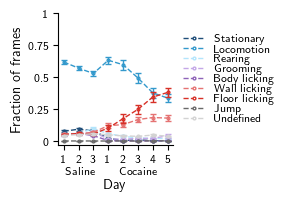

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def setup_output_folder(root_folder):
    output_folder = os.path.join(root_folder, 'Figures', 'Stereotypies_development', 'Summary')
    os.makedirs(output_folder, exist_ok=True)
    return output_folder

def initialize_data_structures(trials, TM):
    num_of_mice = [len(TM[t].keys()) for t in trials]
    max_num_of_mice = max(num_of_mice)
    return num_of_mice, max_num_of_mice

def process_behavior_data(trials, TM, behaviors, lut):
    fraction_of_frames = np.full((len(behaviors), len(trials), max_num_of_mice), np.nan)
    clustered_fraction_of_frames = np.full((3, len(trials), max_num_of_mice), np.nan)

    for t_idx, t in enumerate(trials):
        for m_idx, m in enumerate(TM[t]):
            predictions = TM[t][m]['merged']
            for b, _ in enumerate(behaviors):
                fraction_of_frames[b, t_idx, m_idx] = np.count_nonzero(predictions == b) / predictions.size
            
            clustered_predictions = lut[predictions]
            for i, behavior in enumerate([EGO_LICKING, ALLO_LICKING, NO_LICKING]):
                clustered_fraction_of_frames[i, t_idx, m_idx] = np.count_nonzero(clustered_predictions == behavior) / predictions.size

    return fraction_of_frames, clustered_fraction_of_frames

def plot_behavior_data(fraction_of_frames, num_of_mice, behaviors, colors):
    plt.figure(figsize=(1.83, 1.81))
    new_behavior_order = ['Stationary', 'Locomotion', 'Rearing', 'Grooming', 'Body licking', 'Wall licking', 'Floor licking', 'Jump', 'Undefined']

    for behavior in new_behavior_order:
        b = behaviors.index(behavior)
        mean = np.nanmean(fraction_of_frames[b], axis=1)
        stderr = np.sqrt(np.nanvar(fraction_of_frames[b], axis=1) / np.array(num_of_mice))
        plt.plot(mean, color=colors[b], label=behavior, ls='--', lw=1, marker='o', ms=2, markerfacecolor='white')
        plt.errorbar(np.arange(len(trials)), y=mean, yerr=stderr, color=colors[b], capsize=2, capthick=1, ls='', elinewidth=1)

def customize_plot():
    plt.yticks(np.arange(0, 1.1, 0.25), [0, 0.25, 0.5, 0.75, 1])
    plt.ylabel('Fraction of frames')
    
    xtick_labels = ['1', '2', '3', '1', '2', '3', '4', '5']
    group_labels = ['Saline', 'Cocaine']
    plt.xticks(np.arange(len(xtick_labels)), xtick_labels)
    
    group_positions = [0.18, 0.7]
    for i, label in enumerate(group_labels):
        plt.text(group_positions[i], -0.2, label, ha='center', va='center', transform=plt.gca().transAxes)
    
    plt.subplots_adjust(bottom=0.15, right=0.75)
    plt.xlabel('Day', labelpad=10)
    sns.despine()
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, labelspacing=0.0)

def save_plot(output_folder):
    plt.savefig(os.path.join(output_folder, 'fraction_of_frames_linePlots.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Main execution
output_folder = setup_output_folder(root_folder)
num_of_mice, max_num_of_mice = initialize_data_structures(trials, TM)
fraction_of_frames, clustered_fraction_of_frames = process_behavior_data(trials, TM, behaviors, lut)
plot_behavior_data(fraction_of_frames, num_of_mice, behaviors, colors)
customize_plot()
save_plot(output_folder)

In [3]:
root_folder

'May24'

In [4]:
# Plot clustered behaviors
ego_licking_mean = np.nanmean(clustered_fraction_of_frames[EGO_LICKING], axis=1)
ego_licking_stderr = np.sqrt(np.nanvar(clustered_fraction_of_frames[EGO_LICKING], axis=1) / np.array(num_of_mice))
allo_licking_mean = np.nanmean(clustered_fraction_of_frames[ALLO_LICKING], axis=1)
allo_licking_stderr = np.sqrt(np.nanvar(clustered_fraction_of_frames[ALLO_LICKING], axis=1) / np.array(num_of_mice))
no_licking_mean = np.nanmean(clustered_fraction_of_frames[NO_LICKING], axis=1)
no_licking_stderr = np.sqrt(np.nanvar(clustered_fraction_of_frames[NO_LICKING], axis=1) / np.array(num_of_mice))

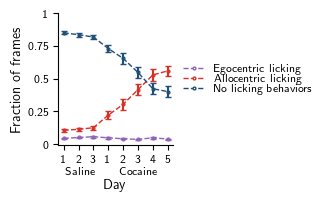

In [5]:

plt.figure(figsize=(1.83, 1.81))
plt.plot(ego_licking_mean, color='#8e63b8', label='Egocentric licking', ls='--', lw=1, marker='o',ms=2, markerfacecolor='white')
plt.errorbar(np.arange(num_of_trials), y=ego_licking_mean, yerr=ego_licking_stderr, color='#8e63b8', capsize=2, capthick=1, ls='')
plt.plot(allo_licking_mean, color='#d73027', label='Allocentric licking', ls='--', lw=1, marker='o',ms=2, markerfacecolor='white')
plt.errorbar(np.arange(num_of_trials), y=allo_licking_mean, yerr=allo_licking_stderr, color='#d73027', capsize=2, capthick=1, ls='')
plt.plot(no_licking_mean, color='#1f4e79', label='No licking behaviors', ls='--', lw=1, marker='o',ms=2, markerfacecolor='white')
plt.errorbar(np.arange(num_of_trials), y=no_licking_mean, yerr=no_licking_stderr, color='#1f4e79', capsize=2, capthick=1, ls='')

# Adjust y-ticks and labels
plt.yticks(np.arange(0, 1.1, 0.25), [0, 0.25, 0.5, 0.75, 1])
plt.ylabel('Fraction of frames')

# Adjust x-axis labels
xtick_labels = ['1', '2', '3', '1', '2', '3', '4', '5']
group_labels = ['Saline', 'Cocaine']
plt.xticks(np.arange(len(xtick_labels)), xtick_labels)

# Add group labels below x-axis labels
group_positions = [0.18, 0.7]
for i, label in enumerate(group_labels):
    plt.text(group_positions[i], -0.2, label, ha='center', va='center', transform=plt.gca().transAxes)

plt.subplots_adjust(bottom=0.15, right=0.75)
plt.xlabel('Day', labelpad=10)
sns.despine()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False, labelspacing=0.0)
plt.show()
# plt.savefig(output_folder + 'fraction_of_frames_linePlots_clustered.pdf', dpi=300)

plt.close()

In [ ]:
#%% CDFs of bout length
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

output_folder = root_folder + '/Figures/Stereotypies_development/Bouts/'
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

colors_prime = [
    "#d3d3d3",  # Light Gray
    "#a9a9a9",  # Medium Gray
    "#808080",  # Dark Gray
    "#ffa500",  # Orange
    "#ff8c00",  # Dark Orange
    "#ff6347",  # Red-Orange
    "#e60000",  # Red
    "#990000"   # Dark Red
]

longest_bout = 400
x_axis = np.arange(longest_bout)
num_of_mice = 0
for t in trials:
    num_of_mice = np.max([num_of_mice, len(TM[t].keys())])
print(num_of_mice)
cdf = np.empty((num_of_behaviors, num_of_trials, num_of_mice, longest_bout))
cdf[:, :, :, :] = np.nan

for b in range(num_of_behaviors):
    plt.figure(figsize=(1.8, 1.8))
    tr_idx = 0
    for tr in trials:
        num_of_bouts = []
        bout_length = []
        m_idx = 0
        for m in TM[tr]:
            predictions = TM[tr][m]['merged']
            bouts_data = np.array(hf.segment_bouts(predictions, b, 8)['length'])
            if bouts_data.size > 0:
                for bl in x_axis:
                    cdf[b, tr_idx, m_idx, bl] = np.count_nonzero(bouts_data <= bl) / bouts_data.size
            m_idx += 1
        mean = np.nanmean(cdf[b, tr_idx, :, :], axis=0)
        stderr = np.sqrt(np.nanvar(cdf[b, tr_idx, :, :], axis=0) / m_idx)
        plt.plot(x_axis, mean, color=colors_prime[tr_idx], alpha=.7, label=tr, linewidth=1)
        plt.fill_between(x_axis, y1=mean-stderr, y2=mean+stderr, color=colors_prime[tr_idx], alpha=.3)
        tr_idx += 1

    sns.despine()
    plt.xlim(0, 200)
    plt.xticks(np.arange(0, 201, 100))
    plt.ylim(0.4, 1)

    plt.xlabel(r'Bout length (\# of frames)')
    plt.ylabel('${P}(|bout| \leq {x}$)')

    plt.tight_layout()
    plt.show()
    # plt.savefig(os.path.join(output_folder, f'bout_length_cdf_{behaviors[b]}.pdf'), dpi=300, bbox_inches='tight')
    plt.close()

In [34]:
edge_color

(0.12156862745098039, 0.3058823529411765, 0.4745098039215686, 0.12)

saline1 c526m3
saline1 c512m7
saline1 c512m3
saline1 c512m4
saline1 c512m6
saline1 c526m2
saline1 c548m1
saline1 c514m5


C:\Users\Ben\AppData\Local\Temp\ipykernel_2060\1425189600.py:31: RuntimeWarning: invalid value encountered in divide
  transition_prob[t_idx,m_idx,b,:]/=np.sum(transition_prob[t_idx,m_idx,b,:])


saline1 c514m3
saline1 c514m1
saline1 c548m8
saline1 c548m10
saline1 cA242m9
saline1 c548m11
saline1 cA242m4
saline1 cA154m4
saline1 cA156m7
saline1 cA156m8
saline1 cA154m6
saline1 cA156m6
saline1 cA156m1
saline1 cA158m3
saline1 cA156m2
saline1 cA156m5
saline1 cA158m2
saline1 cA158m4
saline1 cA242m5
saline1 cA242m8
saline1 cA184m4
saline1 cA184m7
saline1 cA242m6
saline1 cA160m3
saline1 cA186m7
saline1 cA180m5
saline1 cA182m5
saline1 cA182m10
saline1 cA186m6
saline1 cA180m6
saline1 cA182m7
saline2 c526m3
saline2 c512m7
saline2 c512m3
saline2 c512m4
saline2 c512m6
saline2 c526m2
saline2 c548m1
saline2 c514m5
saline2 c514m3
saline2 c514m1
saline2 c548m8
saline2 c548m10
saline2 cA242m9
saline2 c548m11
saline2 cA242m4
saline2 cA154m4
saline2 cA156m7
saline2 cA156m8
saline2 cA154m6
saline2 cA156m6
saline2 cA156m1
saline2 cA158m3
saline2 cA156m2
saline2 cA156m5
saline2 cA158m2
saline2 cA158m4
saline2 cA242m5
saline2 cA242m8
saline2 cA184m4
saline2 cA184m7
saline2 cA242m6
saline2 cA160m3
salin

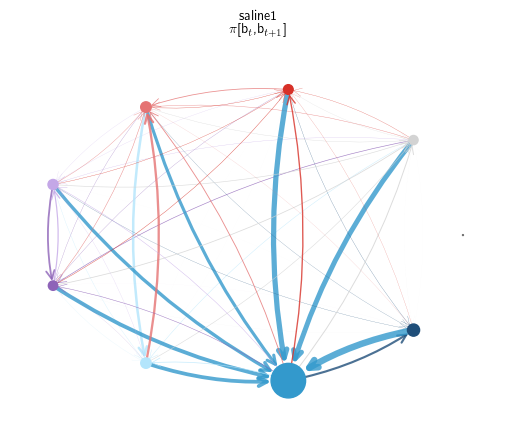

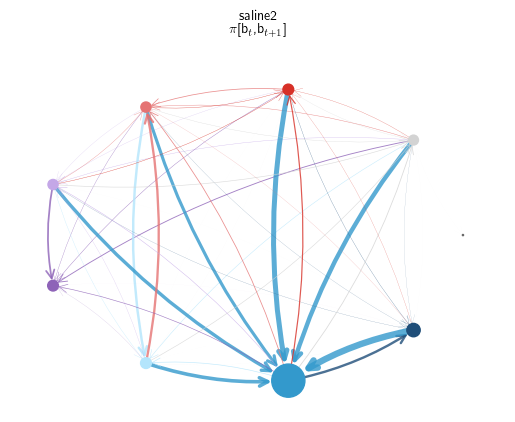

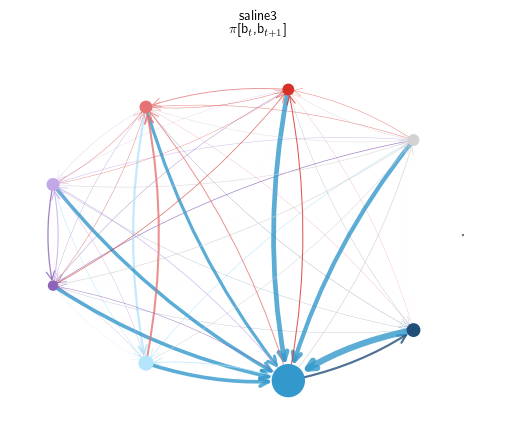

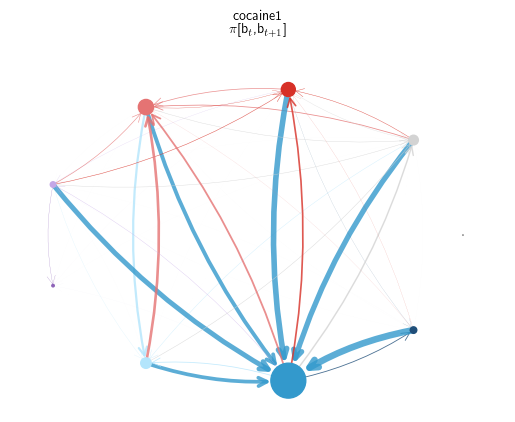

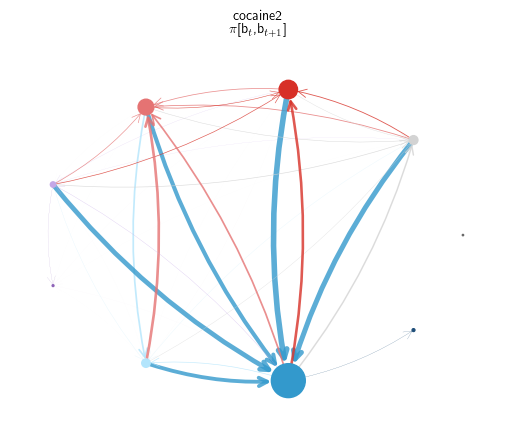

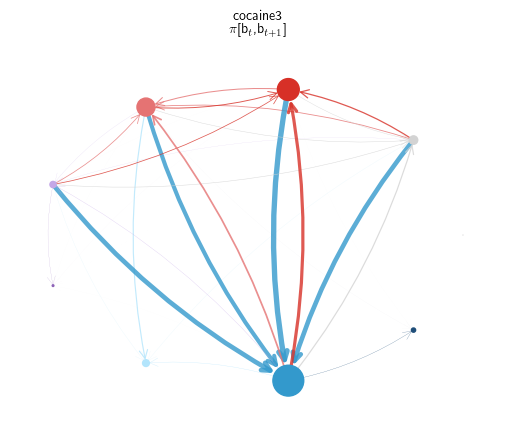

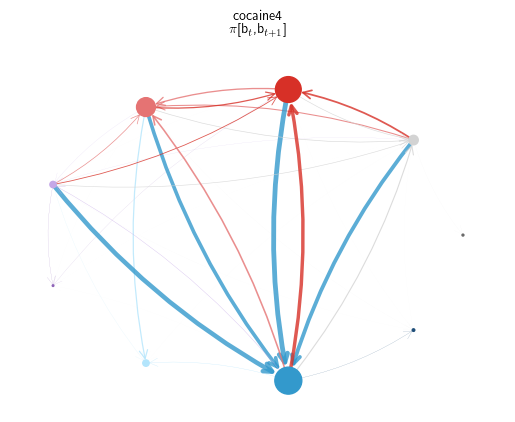

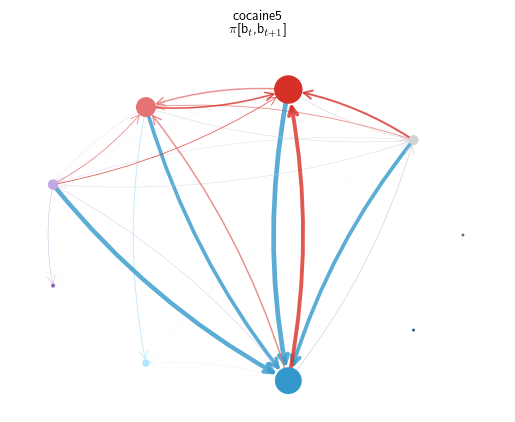

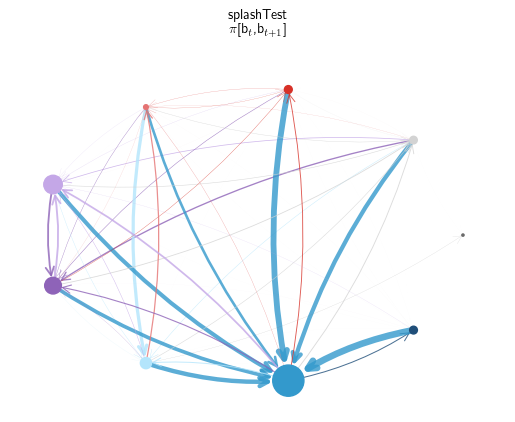

In [5]:
#%% States and actions diagrams for transitions probabilities and time spent in each behavior
output_folder = root_folder+'/Figures/Stereotypies_development/States & Actions/'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

trials_subset = np.copy(trials)
trials_subset = np.append(trials_subset,'splashTest')
num_of_subset_trials = trials_subset.size
num_of_mice = []
for t in trials_subset:
    num_of_mice.append(len(TM[t].keys()))
max_num_of_mice = np.max(num_of_mice)
transition_prob = np.zeros((num_of_subset_trials,max_num_of_mice,num_of_behaviors, num_of_behaviors))
time_spent=np.zeros((num_of_subset_trials,max_num_of_mice,num_of_behaviors))
mice_mean_transition_prob = np.zeros((num_of_subset_trials,num_of_behaviors, num_of_behaviors))
mice_mean_time_spent = np.zeros((num_of_subset_trials,num_of_behaviors))
t_idx=0
for t in trials_subset:
    m_idx = 0
    for m in TM[t]:
        print(t,m)
        predictions = TM[t][m]['merged']
        for i in range(predictions.size-1):
            transition_prob[t_idx,m_idx,predictions[i],predictions[i+1]]+=1
            time_spent[t_idx,m_idx,predictions[i]]+=1
        time_spent[t_idx, m_idx, predictions[-1]] += 1
        time_spent[t_idx, m_idx, :] /= np.sum(time_spent[t_idx, m_idx, :])
        np.fill_diagonal(transition_prob[t_idx, m_idx, :, :], 0)
        for b in range(num_of_behaviors):
            transition_prob[t_idx,m_idx,b,:]/=np.sum(transition_prob[t_idx,m_idx,b,:])
        m_idx+=1
    mice_mean_transition_prob[t_idx,:,:] = np.sum(transition_prob[t_idx,:,:,:],axis=0) / float(num_of_mice[t_idx])
    mice_mean_time_spent[t_idx,:] = np.sum(time_spent[t_idx,:,:], axis=0) / float(num_of_mice[t_idx])
    t_idx+=1

print('Done collecting data')
mice_mean_time_spent*=1000
transition_threshold = 1.0/(num_of_behaviors**2) # randomly selecting behavior and randomly selecting to move to the nexet behavior
aboveChance_alpha=0.8
belowChance_alpha=0.12
for t_idx in range(num_of_subset_trials):
    plt.figure()
    edges = []
    edge_colors = []
    edge_width = []
    
    import matplotlib.colors as mcolors
    
    def hex_to_rgb(hex_color):
        # Convert hex color to RGB tuple
        return mcolors.hex2color(hex_color)
    
    for b_cur in range(num_of_behaviors):
        for b_next in range(num_of_behaviors):
            edges.append((b_cur, b_next, mice_mean_transition_prob[t_idx, b_cur, b_next] * 5))
            edge_color = colors[b_next]
    
            # Check if edge_color is in hex format
            if isinstance(edge_color, str):
                edge_color = hex_to_rgb(edge_color)
            
            # Ensure the edge color is in RGB format (length 3)
            if len(edge_color) == 3:
                # Adjust alpha based on transition probability
                if mice_mean_transition_prob[t_idx, b_cur, b_next] >= transition_threshold:
                    edge_color = edge_color + (aboveChance_alpha,)  # Add alpha to RGB
                else:
                    edge_color = edge_color + (belowChance_alpha,)  # Add alpha to RGB
            else:
                raise ValueError("Expected RGB color with length 3.")
            
            edge_colors.append(edge_color)
    
    G = nx.DiGraph()
    G.add_weighted_edges_from(edges)
    weights = nx.get_edge_attributes(G, 'weight').values()
    plt.title(trials_subset[t_idx] + '\n$\pi$[b$_t$,b$_{t+1}$]')
    nx.draw(G, pos=nx.circular_layout(G), edge_color=edge_colors, node_color=colors, 
            width=list(weights), node_size=mice_mean_time_spent[t_idx], arrowstyle='->',
            arrowsize=15, connectionstyle='arc3, rad = 0.1', with_labels=False)
    # plt.savefig(output_folder + 'states_actions_' + trials_subset[t_idx] + '.pdf', dpi=300)
    plt.show()
    plt.close()

saline1 c526m3
saline1 c512m7
saline1 c512m3
saline1 c512m4
saline1 c512m6
saline1 c526m2
saline1 c548m1
saline1 c514m5
saline1 c514m3
saline1 c514m1
saline1 c548m8


C:\Users\Ben\AppData\Local\Temp\ipykernel_2060\1003119312.py:37: RuntimeWarning: invalid value encountered in divide
  transition_prob[t_idx, m_idx, b, :] /= np.sum(transition_prob[t_idx, m_idx, b, :])


saline1 c548m10
saline1 cA242m9
saline1 c548m11
saline1 cA242m4
saline1 cA154m4
saline1 cA156m7
saline1 cA156m8
saline1 cA154m6
saline1 cA156m6
saline1 cA156m1
saline1 cA158m3
saline1 cA156m2
saline1 cA156m5
saline1 cA158m2
saline1 cA158m4
saline1 cA242m5
saline1 cA242m8
saline1 cA184m4
saline1 cA184m7
saline1 cA242m6
saline1 cA160m3
saline1 cA186m7
saline1 cA180m5
saline1 cA182m5
saline1 cA182m10
saline1 cA186m6
saline1 cA180m6
saline1 cA182m7
saline2 c526m3
saline2 c512m7
saline2 c512m3
saline2 c512m4
saline2 c512m6
saline2 c526m2
saline2 c548m1
saline2 c514m5
saline2 c514m3
saline2 c514m1
saline2 c548m8
saline2 c548m10
saline2 cA242m9
saline2 c548m11
saline2 cA242m4
saline2 cA154m4
saline2 cA156m7
saline2 cA156m8
saline2 cA154m6
saline2 cA156m6
saline2 cA156m1
saline2 cA158m3
saline2 cA156m2
saline2 cA156m5
saline2 cA158m2
saline2 cA158m4
saline2 cA242m5
saline2 cA242m8
saline2 cA184m4
saline2 cA184m7
saline2 cA242m6
saline2 cA160m3
saline2 cA186m7
saline2 cA180m5
saline2 cA182m5
sa

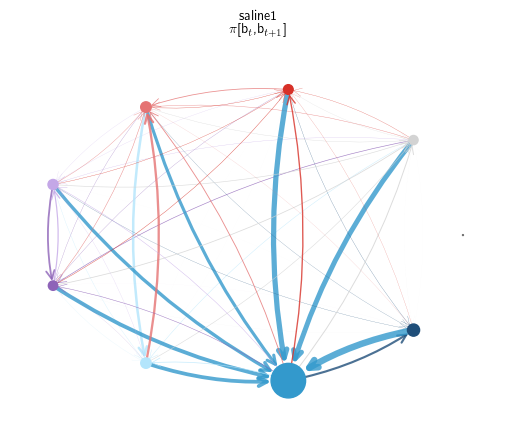

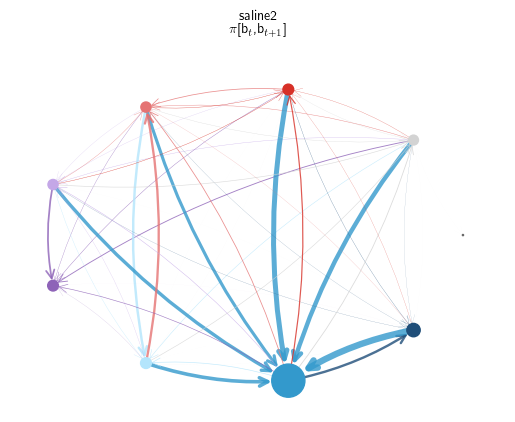

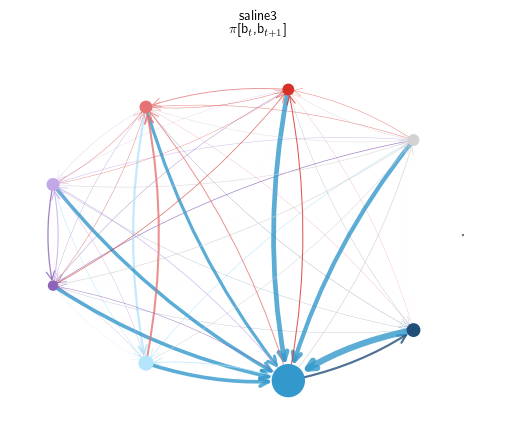

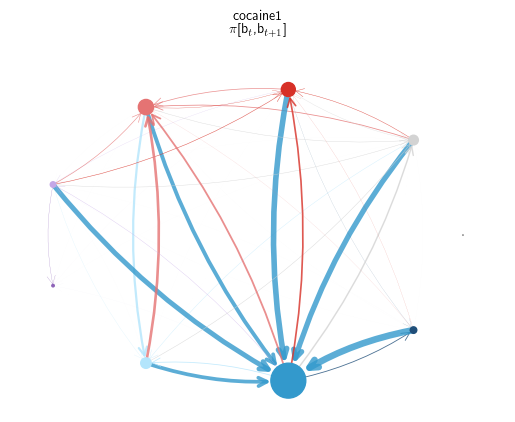

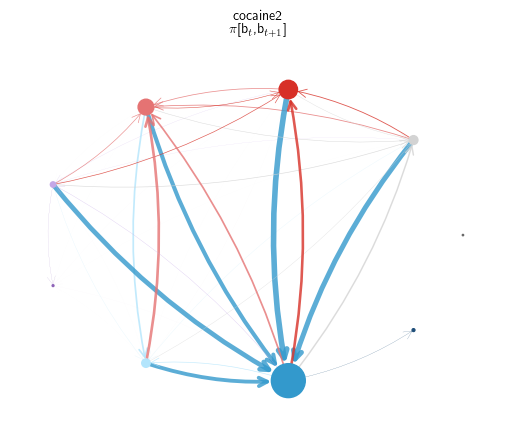

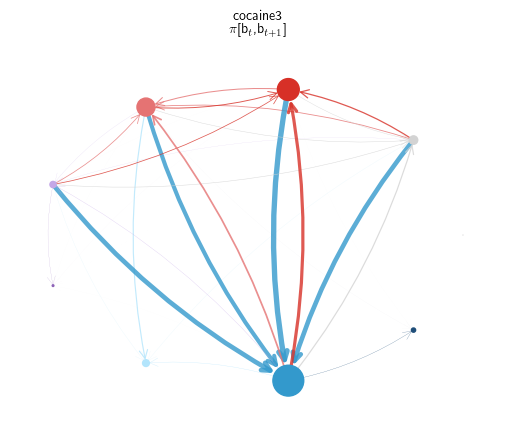

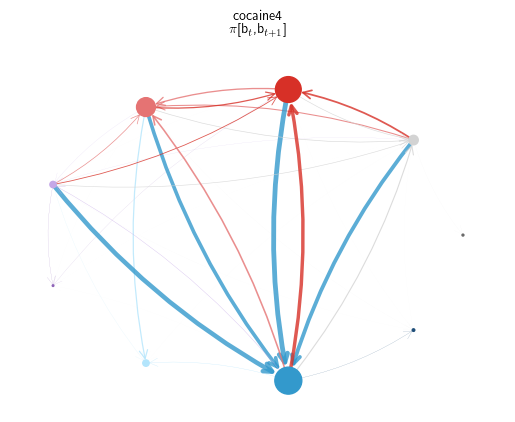

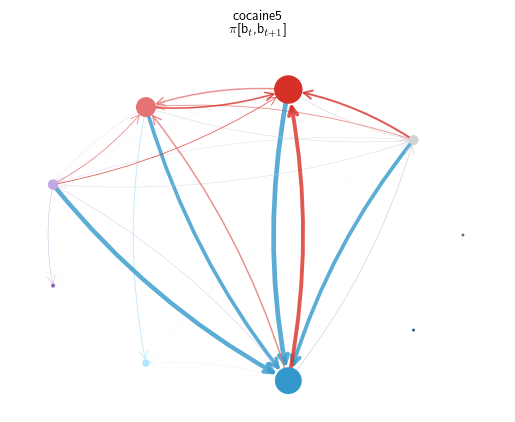

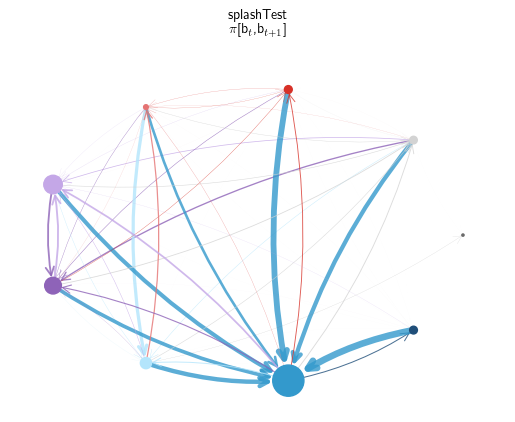

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.colors as mcolors

#%% States and actions diagrams for transitions probabilities and time spent in each behavior
output_folder = root_folder + '/Figures/Stereotypies_development/States & Actions/'

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

trials_subset = np.copy(trials)
trials_subset = np.append(trials_subset, 'splashTest')
num_of_subset_trials = trials_subset.size
num_of_mice = []
for t in trials_subset:
    num_of_mice.append(len(TM[t].keys()))
max_num_of_mice = np.max(num_of_mice)
transition_prob = np.zeros((num_of_subset_trials, max_num_of_mice, num_of_behaviors, num_of_behaviors))
time_spent = np.zeros((num_of_subset_trials, max_num_of_mice, num_of_behaviors))
mice_mean_transition_prob = np.zeros((num_of_subset_trials, num_of_behaviors, num_of_behaviors))
mice_mean_time_spent = np.zeros((num_of_subset_trials, num_of_behaviors))
t_idx = 0
for t in trials_subset:
    m_idx = 0
    for m in TM[t]:
        print(t, m)
        predictions = TM[t][m]['merged']
        for i in range(predictions.size - 1):
            transition_prob[t_idx, m_idx, predictions[i], predictions[i + 1]] += 1
            time_spent[t_idx, m_idx, predictions[i]] += 1
        time_spent[t_idx, m_idx, predictions[-1]] += 1
        time_spent[t_idx, m_idx, :] /= np.sum(time_spent[t_idx, m_idx, :])
        np.fill_diagonal(transition_prob[t_idx, m_idx, :, :], 0)
        for b in range(num_of_behaviors):
            transition_prob[t_idx, m_idx, b, :] /= np.sum(transition_prob[t_idx, m_idx, b, :])
        m_idx += 1
    mice_mean_transition_prob[t_idx, :, :] = np.sum(transition_prob[t_idx, :, :, :], axis=0) / float(num_of_mice[t_idx])
    mice_mean_time_spent[t_idx, :] = np.sum(time_spent[t_idx, :, :], axis=0) / float(num_of_mice[t_idx])
    t_idx += 1

print('Done collecting data')
mice_mean_time_spent *= 1000
transition_threshold = 1.0 / (num_of_behaviors ** 2)  # randomly selecting behavior and randomly selecting to move to the next behavior
aboveChance_alpha = 0.8
belowChance_alpha = 0.12
for t_idx in range(num_of_subset_trials):
    plt.figure()
    edges = []
    edge_colors = []
    edge_width = []

    def hex_to_rgb(hex_color):
        # Convert hex color to RGB tuple
        return mcolors.hex2color(hex_color)

    for b_cur in range(num_of_behaviors):
        for b_next in range(num_of_behaviors):
            edges.append((b_cur, b_next, mice_mean_transition_prob[t_idx, b_cur, b_next] * 5))
            edge_color = colors[b_next]

            # Check if edge_color is in hex format
            if isinstance(edge_color, str):
                edge_color = hex_to_rgb(edge_color)

            # Ensure the edge color is in RGB format (length 3)
            if len(edge_color) == 3:
                # Adjust alpha based on transition probability
                if mice_mean_transition_prob[t_idx, b_cur, b_next] >= transition_threshold:
                    edge_color = edge_color + (aboveChance_alpha,)  # Add alpha to RGB
                else:
                    edge_color = edge_color + (belowChance_alpha,)  # Add alpha to RGB
            else:
                raise ValueError("Expected RGB color with length 3.")

            edge_colors.append(edge_color)

    G = nx.DiGraph()
    G.add_weighted_edges_from(edges)
    weights = nx.get_edge_attributes(G, 'weight').values()
    plt.title(trials_subset[t_idx] + '\n$\pi$[b$_t$,b$_{t+1}$]')
    
    # Filter out non-finite values from weights and node sizes before plotting and saving
    finite_weights = [w if np.isfinite(w) else 0.0 for w in weights]
    finite_node_sizes = [size if np.isfinite(size) else 0.0 for size in mice_mean_time_spent[t_idx]]
    
    nx.draw(G, pos=nx.circular_layout(G), edge_color=edge_colors, node_color=colors,
            width=finite_weights, node_size=finite_node_sizes, arrowstyle='->',
            arrowsize=15, connectionstyle='arc3, rad = 0.1', with_labels=False)
    
    plt.savefig(output_folder + 'states_actions_' + trials_subset[t_idx] + '.pdf', dpi=300)
    plt.show()
    plt.close()
